# 단계 2 — 탐색적 데이터 분석 (EDA)

이더리움 지갑 주소 사기 탐지 데이터를 **모델링 전에 먼저 눈으로 확인**하는 단계입니다.

여기서 답할 질문 5가지:

1. **클래스 불균형** — 사기 주소가 전체의 몇 %인가? (지표 선택에 직결)
2. **결측 열** — 값이 비어 있는 열은 어디이고, 왜 비었을 것 같은가?
3. **쓸모없는 열** — 모든 행이 같은 값인 '상수 열'은 무엇인가?
4. **중복** — 같은 주소가 여러 번 들어간 행이 있는가?
5. **특징 분류** — 47개 특징을 거래 빈도 / 금액 / 시간 간격 / 토큰 활동 4묶음으로

> 이 노트북은 데이터를 **읽기만** 합니다. 값을 바꾸는 가공은 단계 3에서 합니다.

In [1]:
# ── 프로젝트 모듈을 불러올 수 있도록 경로 설정 ──────────────────────
# 노트북은 notebooks/ 폴더에서 실행되므로, 한 단계 위(프로젝트 루트)를
# 파이썬 검색 경로에 추가해야 `from src import ...` 가 동작한다.
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import config, data_loader
from src.plot_style import (
    apply_project_plot_style, CLASS_COLORS, CLASS_LABELS, COLOR_TEXT_SECONDARY,
)

# 그래프 스타일(한글 글꼴 + 색)을 프로젝트 공통 설정으로 맞춘다
applied_font = apply_project_plot_style()
print("적용된 한글 글꼴:", applied_font)

# 표를 넓게 보기 위한 설정
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)

# 원본 데이터 읽기 (열 이름 앞뒤 공백만 제거된 상태)
transactions = data_loader.load_raw_dataset()
print("데이터 크기: {}행 × {}열".format(*transactions.shape))

적용된 한글 글꼴: WenQuanYi Zen Hei
데이터 크기: 9841행 × 51열


---

## 1. 클래스 불균형 — 사기 주소는 전체의 몇 %인가?

**왜 먼저 보나?**
사기 데이터는 보통 사기가 아주 드뭅니다. 만약 사기가 1%라면, 모델이 **무조건 "정상"이라고만
답해도 정확도(accuracy)가 99%** 가 나옵니다. 아무것도 못 잡았는데 성적표는 A+인 셈이죠.
그래서 불균형 정도를 먼저 확인하고, 그에 맞는 지표(AUC·F1)를 골라야 합니다.

In [2]:
# 클래스 균형 요약 (src/data_loader.py 의 함수 사용)
class_balance = data_loader.summarize_class_balance(transactions)

for key, value in class_balance.items():
    print(f"{key:<24} {value:,}" if isinstance(value, int) else f"{key:<24} {value}")

전체 행 수                   9,841
정상(FLAG=0)               7,662
사기(FLAG=1)               2,179
사기 비율(%)                 22.14
불균형 비율(정상:사기)            3.52


findfont: Failed to find font weight normal, now using 500.


findfont: Failed to find font weight normal, now using 500.


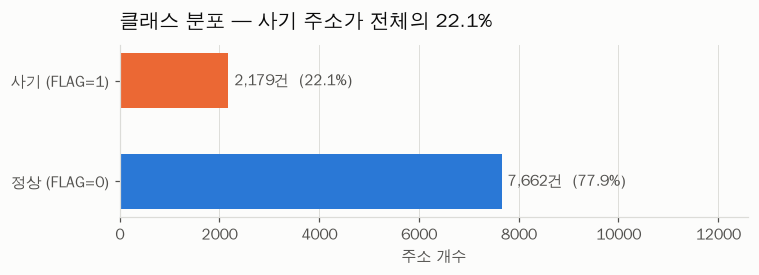

In [3]:
# ── 그림 1: 클래스 분포 ─────────────────────────────────────────────
# 형태 선택: 범주 2개의 '크기 비교'이므로 가로 막대(bar)가 가장 읽기 쉽다.
# 값이 2개뿐이라 축에서 값을 읽게 하지 않고 막대 끝에 숫자를 직접 붙인다.

class_counts = transactions[data_loader.TARGET_COLUMN].value_counts().sort_index()
total_count = len(transactions)

figure, axis = plt.subplots(figsize=(7, 2.6))

bar_positions = [0, 1]
bar_colors = [CLASS_COLORS[0], CLASS_COLORS[1]]
bars = axis.barh(bar_positions, class_counts.values, color=bar_colors, height=0.55)

# 막대 끝에 '개수 (비율%)'를 직접 표시 — 색만으로 정보를 전달하지 않기 위해
for bar, count in zip(bars, class_counts.values):
    percentage = count / total_count * 100
    axis.text(
        bar.get_width() + total_count * 0.012,
        bar.get_y() + bar.get_height() / 2,
        f"{count:,}건  ({percentage:.1f}%)",
        va="center", fontsize=10, color=COLOR_TEXT_SECONDARY,
    )

axis.set_yticks(bar_positions)
axis.set_yticklabels([CLASS_LABELS[0], CLASS_LABELS[1]])
axis.set_xlim(0, total_count * 1.28)
axis.set_xlabel("주소 개수")
axis.set_title("클래스 분포 — 사기 주소가 전체의 22.1%", loc="left", pad=12)
axis.grid(axis="y", visible=False)   # 가로 막대에서는 세로 격자만 의미가 있다

figure.tight_layout()

# 보고서용으로 저장
config.ensure_directories_exist()
figure.savefig(config.FIGURES_DIRECTORY / "01_class_balance.png", dpi=150, bbox_inches="tight")
plt.show()

### 해석

- 사기 주소가 **22.1% (2,179건)** 입니다. 정상:사기 = **3.52 : 1**.
- 실제 금융 사기 데이터(보통 0.1~1%)에 비하면 **훨씬 균형 잡힌 편**입니다.
  Kaggle 제작자가 사기 주소를 의도적으로 많이 모아 만든 데이터로 보입니다.
- **실무적 함의**: 불균형이 심하지 않으므로 SMOTE 같은 과격한 오버샘플링은 굳이 필요 없습니다.
  다만 정확도(accuracy)는 여전히 부적절한 지표입니다 — 전부 "정상"이라고 답해도 77.9%가 나오니까요.
  그래서 단계 4에서 **AUC · KS · F1(사기 클래스 기준)** 을 씁니다.
- **주의**: 이 22.1%는 현실의 사기 비율이 아닙니다. 실제 서비스에 올릴 때는
  현실 비율에 맞춰 임계값을 다시 잡아야 합니다 (단계 6에서 다룸).

---

## 2. 결측 열 — 어디가 비어 있고, 왜 비었을까?

In [4]:
missing_table = data_loader.build_missing_value_table(transactions)
print(f"결측이 있는 열: {len(missing_table)}개 / 전체 {transactions.shape[1]}개\n")
missing_table

결측이 있는 열: 25개 / 전체 51개



,결측 개수,결측 비율(%)
ERC20 most sent token type,2697,27.41
ERC20_most_rec_token_type,871,8.85
ERC20 total ether sent,829,8.42
ERC20 total Ether received,829,8.42
ERC20 uniq sent addr,829,8.42
ERC20 uniq rec addr,829,8.42
ERC20 uniq sent addr.1,829,8.42
ERC20 total Ether sent contract,829,8.42
Total ERC20 tnxs,829,8.42
ERC20 avg time between sent tnx,829,8.42


In [5]:
# 결측이 '무작위로' 생긴 것인지, '규칙적으로' 생긴 것인지 확인한다.
# 만약 ERC20 관련 열들이 항상 '같은 행'에서 함께 비어 있다면,
# 그것은 오류가 아니라 "이 지갑은 토큰 거래를 한 적이 없다"는 뜻일 가능성이 높다.

# pandas 버전에 따라 문자열 dtype 이 'object' 또는 'str' 로 달라진다.
# 그래서 dtype 을 직접 비교하지 말고 pandas 가 제공하는 판별 함수를 쓴다.
erc20_numeric_columns = [
    column for column in data_loader.TOKEN_ACTIVITY_FEATURES
    if pd.api.types.is_numeric_dtype(transactions[column])
]

# 각 행에서 ERC20 열이 몇 개나 비어 있는지 센다
erc20_missing_per_row = transactions[erc20_numeric_columns].isna().sum(axis=1)

print("한 행에서 비어 있는 ERC20 열 개수의 분포:")
print(erc20_missing_per_row.value_counts().sort_index().to_string())
print()
print("→ 0개(전부 채워짐) 또는 전부 비어 있음, 두 가지로만 갈린다면")
print("  결측은 '토큰 거래 이력 없음'을 뜻하는 규칙적 결측이다.")

한 행에서 비어 있는 ERC20 열 개수의 분포:
0     9012
23     829

→ 0개(전부 채워짐) 또는 전부 비어 있음, 두 가지로만 갈린다면
  결측은 '토큰 거래 이력 없음'을 뜻하는 규칙적 결측이다.


In [6]:
# 결측 여부가 사기 여부와 관련이 있는지 확인 (중요!)
# 만약 '토큰 거래 이력 없음'이 사기와 강하게 연관된다면, 그 자체가 좋은 특징이 된다.

has_no_erc20_history = transactions["Total ERC20 tnxs"].isna()

crosstab = pd.crosstab(
    has_no_erc20_history.map({True: "ERC20 이력 없음", False: "ERC20 이력 있음"}),
    transactions[data_loader.TARGET_COLUMN].map(CLASS_LABELS),
    margins=True, margins_name="합계",
)
print(crosstab.to_string())
print()

fraud_rate_when_missing = transactions.loc[has_no_erc20_history, "FLAG"].mean()
fraud_rate_when_present = transactions.loc[~has_no_erc20_history, "FLAG"].mean()
print(f"ERC20 이력 없음 → 사기 비율 {fraud_rate_when_missing*100:.1f}%")
print(f"ERC20 이력 있음 → 사기 비율 {fraud_rate_when_present*100:.1f}%")

FLAG              사기 (FLAG=1)  정상 (FLAG=0)    합계
Total ERC20 tnxs                                
ERC20 이력 없음               829            0   829
ERC20 이력 있음              1350         7662  9012
합계                       2179         7662  9841

ERC20 이력 없음 → 사기 비율 100.0%
ERC20 이력 있음 → 사기 비율 15.0%


### 🚨 해석 — 심각한 문제 발견

결측 패턴 자체는 규칙적입니다. ERC20 숫자 열 **23개가 정확히 같은 829행에서 함께** 비어 있으니,
무작위 오류가 아니라 **"이 지갑은 ERC20 토큰 거래 기록이 수집되지 않았다"** 는 뜻입니다.

**그런데 교차표의 숫자가 이상합니다:**

| | 사기(FLAG=1) | 정상(FLAG=0) |
|---|---|---|
| ERC20 이력 **없음** | **829** | **0** |
| ERC20 이력 있음 | 1,350 | 7,662 |

**ERC20 값이 비어 있는 829행은 100% 사기입니다. 정상 주소는 단 한 건도 없습니다.**

이건 "사기꾼은 토큰 거래를 안 한다"는 발견이 아닙니다.
**데이터를 만든 방식 때문에 생긴 인공적인 흔적(데이터 누수, data leakage)** 입니다.
사기 주소 목록과 정상 주소 목록을 **서로 다른 시점·다른 방법으로 수집해서 붙였기 때문에**,
"값이 비었다"는 사실만으로 정답을 맞힐 수 있게 되어 버린 겁니다.

**왜 이게 문제인가?**
모델이 "ERC20 값이 비었으면 사기"라는 규칙 하나만 외우면 됩니다. 성능 지표는 화려하게 나오지만,
실제 서비스에 올리면 **아무것도 못 잡습니다.** 현실의 새 지갑 주소에는 이런 흔적이 없으니까요.

> 비유: 시험지에 정답이 연필로 흐리게 적혀 있는 걸 발견한 상황입니다.
> 그걸 보고 100점을 맞아도 실력이 늘지는 않죠.

바로 아래에서 누수가 얼마나 심한지 정확히 재 보겠습니다.

---

## 2-B. 데이터 누수(leakage) 정밀 점검

발견한 문제가 얼마나 큰지 **숫자로** 확인합니다. 세 가지를 봅니다.

1. `Total ERC20 tnxs` 한 열의 상태(비어있음 / 0 / 0보다 큼)만으로 정답이 갈리는가?
2. 그 829행은 다른 열들도 특이한가?
3. 원본 CSV의 **행 순서**에 수집 흔적이 남아 있는가?

In [7]:
# ── 점검 1: 단 하나의 열 상태만으로 정답이 갈리는가? ────────────────
erc20_is_missing = transactions["Total ERC20 tnxs"].isna()
erc20_is_zero = (~erc20_is_missing) & (transactions["Total ERC20 tnxs"] == 0)
erc20_is_positive = (~erc20_is_missing) & (transactions["Total ERC20 tnxs"] > 0)

leakage_rows = []
for state_label, row_mask in [
    ("비어 있음 (NaN)", erc20_is_missing),
    ("값이 0", erc20_is_zero),
    ("값이 0보다 큼", erc20_is_positive),
]:
    leakage_rows.append({
        "Total ERC20 tnxs 상태": state_label,
        "행 수": int(row_mask.sum()),
        "사기 수": int(transactions.loc[row_mask, "FLAG"].sum()),
        "사기 비율(%)": round(transactions.loc[row_mask, "FLAG"].mean() * 100, 1),
    })

leakage_table = pd.DataFrame(leakage_rows)
print(leakage_table.to_string(index=False))

# 정답이 '완벽하게' 갈리는 행이 전체의 몇 %인지 계산
perfectly_separated_rows = int(erc20_is_missing.sum() + erc20_is_zero.sum())
print(f"\n사기 비율이 100% 또는 0% 인 구간의 행 수: {perfectly_separated_rows:,}행")
print(f"→ 전체의 {perfectly_separated_rows / len(transactions) * 100:.1f}% 가")
print("  이 열 하나만 보고도 정답을 알 수 있습니다.")

Total ERC20 tnxs 상태  행 수  사기 수  사기 비율(%)
        비어 있음 (NaN)  829   829     100.0
               값이 0 4399     0       0.0
           값이 0보다 큼 4613  1350      29.3

사기 비율이 100% 또는 0% 인 구간의 행 수: 5,228행
→ 전체의 53.1% 가
  이 열 하나만 보고도 정답을 알 수 있습니다.


In [8]:
# ── 점검 2: 그 829행은 다른 열도 특이한가? ─────────────────────────
# 사기 집단을 둘로 쪼개서 비교한다:
#   (a) 사기이면서 ERC20 이력 있음 (1,350행)
#   (b) 사기이면서 ERC20 이력 없음 (829행)  <- 문제의 집단
# 만약 (b)가 (a)와도 크게 다르다면, (b)는 '다른 방식으로 수집된 별종'이라는 뜻이다.

non_token_features = (
    data_loader.TRANSACTION_FREQUENCY_FEATURES
    + data_loader.MONETARY_VALUE_FEATURES
    + data_loader.TIME_INTERVAL_FEATURES
)

mask_normal = transactions["FLAG"] == 0
mask_fraud_with_token = (transactions["FLAG"] == 1) & (~erc20_is_missing)
mask_fraud_without_token = (transactions["FLAG"] == 1) & erc20_is_missing

subgroup_rows = []
for feature_name in non_token_features:
    subgroup_rows.append({
        "특징": feature_name,
        "정상 (7,662)": transactions.loc[mask_normal, feature_name].median(),
        "사기·토큰이력O (1,350)": transactions.loc[mask_fraud_with_token, feature_name].median(),
        "사기·토큰이력X (829)": transactions.loc[mask_fraud_without_token, feature_name].median(),
    })

subgroup_comparison = pd.DataFrame(subgroup_rows).round(3)
subgroup_comparison

,특징,"정상 (7,662)","사기·토큰이력O (1,350)",사기·토큰이력X (829)
0,Sent tnx,3.000,1.000,0.000
1,Received Tnx,5.000,5.000,1.000
2,Number of Created Contracts,0.000,0.000,0.000
3,Unique Received From Addresses,2.000,4.000,1.000
4,Unique Sent To Addresses,2.000,1.000,0.000
5,total transactions (including tnx to create co...,11.000,7.000,3.000
6,min value received,0.157,0.010,0.000
7,max value received,12.217,1.481,0.030
8,avg val received,3.747,0.671,0.019
9,min val sent,0.055,0.052,0.000


In [9]:
# ── 점검 3: 원본 CSV의 행 순서에 수집 흔적이 있는가? ────────────────
# 데이터를 잘 섞어서 만들었다면, 어느 구간을 잘라 봐도 사기 비율이 비슷해야 한다.
# 만약 앞쪽은 전부 정상, 뒤쪽은 전부 사기라면 '두 파일을 그냥 이어붙인' 것이다.

CHUNK_SIZE = 1000
order_rows = []
for start_index in range(0, len(transactions), CHUNK_SIZE):
    chunk = transactions.iloc[start_index : start_index + CHUNK_SIZE]
    order_rows.append({
        "행 구간": f"{start_index:,} ~ {min(start_index + CHUNK_SIZE, len(transactions)):,}",
        "행 수": len(chunk),
        "사기 비율(%)": round(chunk["FLAG"].mean() * 100, 1),
        "ERC20 결측 비율(%)": round(chunk["Total ERC20 tnxs"].isna().mean() * 100, 1),
    })

row_order_table = pd.DataFrame(order_rows)
print(row_order_table.to_string(index=False))

         행 구간  행 수  사기 비율(%)  ERC20 결측 비율(%)
    0 ~ 1,000 1000       0.0             0.0
1,000 ~ 2,000 1000       0.0             0.0
2,000 ~ 3,000 1000       0.0             0.0
3,000 ~ 4,000 1000       0.0             0.0
4,000 ~ 5,000 1000       0.0             0.0
5,000 ~ 6,000 1000       0.0             0.0
6,000 ~ 7,000 1000       0.0             0.0
7,000 ~ 8,000 1000      33.8            13.3
8,000 ~ 9,000 1000     100.0            37.7
9,000 ~ 9,841  841     100.0            37.9


### 점검 결과 — 세 가지 모두 누수를 가리킵니다

**1) 열 하나로 절반이 결정됩니다**

| `Total ERC20 tnxs` 상태 | 행 수 | 사기 비율 |
|---|---|---|
| 비어 있음 (NaN) | 829 | **100.0%** |
| 값이 0 | 4,399 | **0.0%** |
| 값이 0보다 큼 | 4,613 | 29.3% |

`NaN → 무조건 사기`, `0 → 무조건 정상`. **전체 9,841행 중 5,228행(53.1%)** 이
이 열 하나의 상태만으로 정답이 완벽하게 갈립니다. 이건 예측이 아니라 **정답 유출**입니다.

**2) 문제의 829행은 거의 모든 값이 0입니다**

`Sent tnx` 중앙값 0, `total Ether sent` 0, `avg val sent` 0 ...
정상 주소(중앙값 3건, 34 Ether)나 다른 사기 주소(1건, 2.3 Ether)와 비교하면
**거의 아무 활동 기록이 없는 껍데기 행**입니다. 실제로 활동이 없는 지갑일 수도 있지만,
**수집이 제대로 안 된 행**일 가능성이 더 큽니다.

**3) 행 순서가 결정적 증거입니다**

앞 7,000행은 **사기가 0%**, 8,000행 이후는 **사기가 100%** 입니다.
정상 주소 파일과 사기 주소 파일을 **그냥 위아래로 이어붙인** 데이터입니다.
두 파일이 다른 시점·다른 도구로 수집됐다면, 그 차이가 값에도 배어 있을 수밖에 없습니다.

### 그래서 어떻게 할 것인가 (단계 3에서 결정)

이 데이터로 그냥 모델을 만들면 **AUC 0.99 같은 숫자가 나오지만 아무 의미가 없습니다.**
Kaggle 공개 노트북 상당수가 이 함정에 빠져 있습니다.
단계 3에서 **누수 특징을 쓴 모델과 뺀 모델을 둘 다 만들어 비교**할 것을 제안합니다.

---

## 3. 쓸모없는 열 — 모든 행이 같은 값인 '상수 열'

**왜 문제인가?** 반 학생 전원의 점수가 100점이면, 그 점수로는 누가 잘했는지 구분할 수 없습니다.
마찬가지로 모든 행이 같은 값인 열은 사기/정상 구분에 **정보를 0만큼** 줍니다.
게다가 WoE·IV 계산(단계 3)에서 0으로 나누기 오류를 일으키므로 **미리 제거**해야 합니다.

In [10]:
constant_columns = data_loader.find_constant_columns(transactions)

print(f"상수 열 {len(constant_columns)}개:\n")
for column_name in constant_columns:
    unique_values = transactions[column_name].dropna().unique()
    non_null_count = transactions[column_name].notna().sum()
    print(f"  {column_name:<40} 유일값={unique_values}  (결측 아닌 행 {non_null_count:,}개)")

상수 열 7개:

  ERC20 avg time between sent tnx          유일값=[0.]  (결측 아닌 행 9,012개)
  ERC20 avg time between rec tnx           유일값=[0.]  (결측 아닌 행 9,012개)
  ERC20 avg time between rec 2 tnx         유일값=[0.]  (결측 아닌 행 9,012개)
  ERC20 avg time between contract tnx      유일값=[0.]  (결측 아닌 행 9,012개)
  ERC20 min val sent contract              유일값=[0.]  (결측 아닌 행 9,012개)
  ERC20 max val sent contract              유일값=[0.]  (결측 아닌 행 9,012개)
  ERC20 avg val sent contract              유일값=[0.]  (결측 아닌 행 9,012개)


### 해석

상수 열 **7개**가 발견됐고, 모두 값이 **0**이며 모두 ERC20 관련입니다:

| 열 | 왜 전부 0일까 |
|---|---|
| `ERC20 avg time between sent tnx` | 토큰 거래의 **시간 간격이 아예 수집되지 않은** 것으로 보임 |
| `ERC20 avg time between rec tnx` | 위와 같음 |
| `ERC20 avg time between rec 2 tnx` | 위와 같음 (`rec 2`의 의미도 불명 — **확인 필요**) |
| `ERC20 avg time between contract tnx` | 위와 같음 |
| `ERC20 min val sent contract` | 컨트랙트로 **토큰을 보낸 사례가 데이터에 없음** |
| `ERC20 max val sent contract` | 위와 같음 |
| `ERC20 avg val sent contract` | 위와 같음 |

→ 이 7개는 **단계 3에서 제거**합니다. 47개 특징 중 40개가 남습니다.

---

## 4. 중복 — 같은 주소가 여러 번 들어갔는가?

In [11]:
address_column = "Address"

duplicate_address_count = transactions.duplicated(subset=[address_column]).sum()
print(f"중복된 Address 를 가진 행: {duplicate_address_count}개")

# 식별자 열을 뺀 나머지가 완전히 똑같은 행 (= 진짜 완전 중복)
feature_and_target_columns = [
    column for column in transactions.columns
    if column not in ["Unnamed: 0", "Index"]
]
fully_duplicated_count = transactions[feature_and_target_columns].duplicated().sum()
print(f"식별번호를 뺀 나머지가 완전히 같은 행: {fully_duplicated_count}개")

# 중복된 주소들이 서로 다른 FLAG 를 갖는지 확인 (라벨 충돌 여부)
duplicated_addresses = transactions[address_column][
    transactions.duplicated(subset=[address_column], keep=False)
].unique()

label_conflict_count = 0
for address in duplicated_addresses:
    flags_for_address = transactions.loc[transactions[address_column] == address, "FLAG"].unique()
    if len(flags_for_address) > 1:
        label_conflict_count += 1

print(f"\n중복 주소 종류: {len(duplicated_addresses)}개")
print(f"그중 정답(FLAG)이 서로 다른 주소: {label_conflict_count}개")

중복된 Address 를 가진 행: 25개
식별번호를 뺀 나머지가 완전히 같은 행: 18개



중복 주소 종류: 25개
그중 정답(FLAG)이 서로 다른 주소: 0개


### 해석

- 중복 주소가 **25개 행** 있습니다 (전체의 0.25%). 라벨 충돌이 없다면 단순 중복 수집입니다.
- 양이 적어 성능에 큰 영향은 없지만, **교차검증에서 같은 주소가 학습셋과 검증셋에 나뉘어 들어가면
  성능이 부풀려집니다**(정답을 미리 본 셈이 되므로). 단계 3에서 제거합니다.

---

## 5. 특징 47개를 4묶음으로

**왜 묶나?** 47개를 한 줄로 늘어놓으면 머리에 안 들어옵니다.
"이 지갑은 **얼마나 자주**, **얼마씩**, **어떤 간격으로**, **토큰은 어떻게** 거래했나"
라는 4개의 질문으로 묶으면 모델 해석이 훨씬 쉬워집니다.

| 묶음 | 답하는 질문 | 단위 |
|---|---|---|
| **거래 빈도** | 몇 번 거래했나? 상대는 몇 명인가? | 개수 |
| **금액** | 얼마를 주고받았나? | Ether |
| **시간 간격** | 얼마나 자주, 얼마나 오래 활동했나? | 분 |
| **토큰 활동** | ERC20 토큰 세계에서는 어떻게 행동했나? | 혼합 |

In [12]:
# 4묶음 표 만들기 — 각 열의 묶음, 측정 축, 결측, 상수 여부를 한눈에
group_table_rows = []

for group_name, column_names in data_loader.FEATURE_GROUPS.items():
    for column_name in column_names:
        column_series = transactions[column_name]
        group_table_rows.append({
            "묶음": group_name,
            "열 이름": column_name,
            "측정 축": data_loader.FEATURE_MEASUREMENT_AXIS.get(column_name, group_name),
            "자료형": str(column_series.dtype),
            "결측": int(column_series.isna().sum()),
            "고유값": int(column_series.nunique(dropna=True)),
            "상수열": "예" if column_name in constant_columns else "",
            "확인필요": "예" if column_name in data_loader.COLUMNS_NEEDING_VERIFICATION else "",
        })

feature_group_table = pd.DataFrame(group_table_rows)

print("묶음별 특징 개수:")
print(feature_group_table["묶음"].value_counts().to_string())
print(f"\n합계: {len(feature_group_table)}개")

묶음별 특징 개수:
묶음
토큰 활동    25
금액       13
거래 빈도     6
시간 간격     3

합계: 47개


In [13]:
# 전체 표 출력 (47행)
feature_group_table

,묶음,열 이름,측정 축,자료형,결측,고유값,상수열,확인필요
0,거래 빈도,Sent tnx,거래 빈도,int64,0,641,,
1,거래 빈도,Received Tnx,거래 빈도,int64,0,727,,
2,거래 빈도,Number of Created Contracts,거래 빈도,int64,0,20,,
3,거래 빈도,Unique Received From Addresses,거래 빈도,int64,0,256,,
4,거래 빈도,Unique Sent To Addresses,거래 빈도,int64,0,258,,
5,거래 빈도,total transactions (including tnx to create co...,거래 빈도,int64,0,897,,
6,금액,min value received,금액,float64,0,4589,,
7,금액,max value received,금액,float64,0,6302,,
8,금액,avg val received,금액,float64,0,6767,,
9,금액,min val sent,금액,float64,0,4719,,


In [14]:
# 이 표를 보고서로도 저장해 둔다 (깃에서 바로 읽을 수 있도록)
group_summary_lines = ["# 특징 4묶음 분류표", ""]
group_summary_lines.append(f"전체 특징 **{len(feature_group_table)}개**를 4묶음으로 분류했습니다.")
group_summary_lines.append("")
group_summary_lines.append("| 묶음 | 개수 | 상수 열 | 확인 필요 |")
group_summary_lines.append("|---|---|---|---|")
for group_name in data_loader.FEATURE_GROUPS:
    subset = feature_group_table[feature_group_table["묶음"] == group_name]
    group_summary_lines.append(
        f"| {group_name} | {len(subset)} | {(subset['상수열']=='예').sum()} | {(subset['확인필요']=='예').sum()} |"
    )
group_summary_lines.append("")
group_summary_lines.append("---")
group_summary_lines.append("")
group_summary_lines.append(feature_group_table.to_markdown(index=False))

output_path = config.REPORTS_DIRECTORY / "feature_groups.md"
output_path.write_text("\n".join(group_summary_lines), encoding="utf-8")
print(f"저장 완료: {output_path}")

저장 완료: /home/user/blockchain/reports/feature_groups.md


---

## 6. 사기 주소와 정상 주소는 실제로 다르게 생겼는가?

묶음별로 대표 특징을 하나씩 뽑아 두 집단의 분포를 비교합니다.

**로그 축을 쓰는 이유**: 거래 금액이나 횟수는 0에 몰린 지갑이 대부분인데
몇몇 지갑은 수천~수만 배 큽니다. 보통 축으로 그리면 대부분이 바닥에 눌려 아무것도 안 보입니다.
그래서 `log(1 + x)` 로 변환합니다. `+1` 을 하는 이유는 값이 0일 때 `log(0) = -무한대`가 되기 때문입니다.

findfont: Failed to find font weight normal, now using 500.


findfont: Failed to find font weight normal, now using 500.


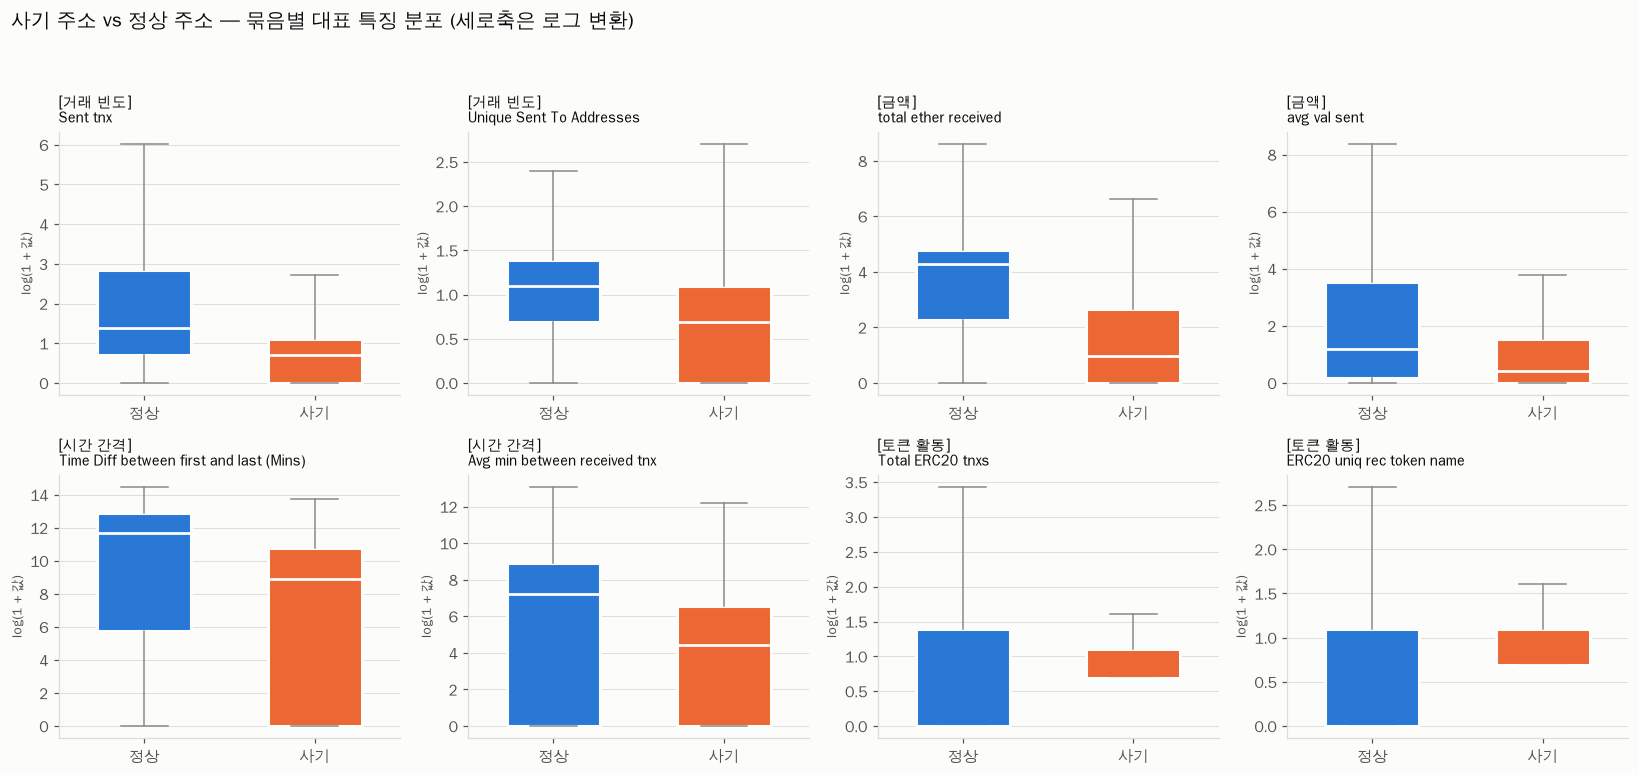

In [15]:
# 묶음별 대표 특징 2개씩 = 총 8개
representative_features = [
    ("거래 빈도", "Sent tnx"),
    ("거래 빈도", "Unique Sent To Addresses"),
    ("금액", "total ether received"),
    ("금액", "avg val sent"),
    ("시간 간격", "Time Diff between first and last (Mins)"),
    ("시간 간격", "Avg min between received tnx"),
    ("토큰 활동", "Total ERC20 tnxs"),
    ("토큰 활동", "ERC20 uniq rec token name"),
]

figure, axes = plt.subplots(2, 4, figsize=(15, 7))
axes_flat = axes.flatten()

for axis, (group_name, feature_name) in zip(axes_flat, representative_features):
    # 결측은 여기서 제외하고 그린다(결측 처리는 단계 3에서 결정)
    normal_values = transactions.loc[transactions["FLAG"] == 0, feature_name].dropna()
    fraud_values = transactions.loc[transactions["FLAG"] == 1, feature_name].dropna()

    # log(1+x) 변환: 자릿수가 크게 다른 값들을 한 화면에 보이게 만든다
    normal_transformed = np.log1p(normal_values.clip(lower=0))
    fraud_transformed = np.log1p(fraud_values.clip(lower=0))

    box_plot = axis.boxplot(
        [normal_transformed, fraud_transformed],
        positions=[0, 1], widths=0.55, patch_artist=True,
        showfliers=False,                       # 극단값 점은 생략(분포 몸통에 집중)
        medianprops=dict(color="white", linewidth=1.8),
        whiskerprops=dict(color="#8a8a86", linewidth=1.0),
        capprops=dict(color="#8a8a86", linewidth=1.0),
    )
    for patch, class_value in zip(box_plot["boxes"], [0, 1]):
        patch.set_facecolor(CLASS_COLORS[class_value])
        patch.set_edgecolor("#fcfcfb")          # 두 상자 사이에 얇은 배경색 틈
        patch.set_linewidth(2)

    axis.set_xticks([0, 1])
    axis.set_xticklabels(["정상", "사기"])
    axis.set_title(f"[{group_name}]\n{feature_name}", fontsize=9.5, loc="left")
    axis.set_ylabel("log(1 + 값)", fontsize=8.5)
    axis.grid(axis="x", visible=False)

figure.suptitle(
    "사기 주소 vs 정상 주소 — 묶음별 대표 특징 분포 (세로축은 로그 변환)",
    fontsize=13, x=0.01, ha="left", y=1.0,
)
figure.tight_layout(rect=[0, 0, 1, 0.96])
figure.savefig(config.FIGURES_DIRECTORY / "02_feature_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

In [16]:
# 그림만으로는 '얼마나' 다른지 숫자로 말하기 어렵다. 중앙값 비교표를 만든다.
# 중앙값(median)을 쓰는 이유: 평균은 극단값 하나에 크게 흔들리지만 중앙값은 안정적이다.

comparison_rows = []
for group_name, column_names in data_loader.FEATURE_GROUPS.items():
    for feature_name in column_names:
        column_series = transactions[feature_name]
        # 문자열 열(토큰 이름)과 상수 열은 중앙값 비교가 의미 없으므로 건너뛴다
        if not pd.api.types.is_numeric_dtype(column_series) or feature_name in constant_columns:
            continue

        normal_median = column_series[transactions["FLAG"] == 0].median()
        fraud_median = column_series[transactions["FLAG"] == 1].median()

        comparison_rows.append({
            "묶음": group_name,
            "특징": feature_name,
            "정상 중앙값": normal_median,
            "사기 중앙값": fraud_median,
            "차이(사기-정상)": fraud_median - normal_median,
        })

median_comparison = pd.DataFrame(comparison_rows)

# '두 집단이 얼마나 다른가'를 하나의 숫자로: 중앙값 차이를 전체 표준편차로 나눈 값
# (표준화된 차이. 절댓값이 클수록 두 집단이 뚜렷이 갈린다는 뜻)
standardized_differences = []
for _, row in median_comparison.iterrows():
    overall_std = transactions[row["특징"]].std()
    standardized_differences.append(
        row["차이(사기-정상)"] / overall_std if overall_std and overall_std > 0 else 0.0
    )
median_comparison["표준화 차이"] = standardized_differences

print("두 집단 차이가 큰 상위 12개 특징 (표준화 차이의 절댓값 기준):\n")
median_comparison.reindex(
    median_comparison["표준화 차이"].abs().sort_values(ascending=False).index
).head(12).round(4)

두 집단 차이가 큰 상위 12개 특징 (표준화 차이의 절댓값 기준):



,묶음,특징,정상 중앙값,사기 중앙값,차이(사기-정상),표준화 차이
21,시간 간격,Time Diff between first and last (Mins),116626.0000,7545.4300,-109080.5700,-0.3378
37,토큰 활동,ERC20 uniq rec token name,0.0000,1.0000,1.0000,0.0600
29,토큰 활동,ERC20 uniq rec contract addr,0.0000,1.0000,1.0000,0.0580
20,시간 간격,Avg min between received tnx,1402.1350,82.0700,-1320.0650,-0.0572
27,토큰 활동,ERC20 uniq rec addr,0.0000,1.0000,1.0000,0.0122
11,금액,avg val sent,2.3097,0.4991,-1.8106,-0.0076
5,거래 빈도,total transactions (including tnx to create co...,11.0000,5.0000,-6.0000,-0.0044
4,거래 빈도,Unique Sent To Addresses,2.0000,1.0000,-1.0000,-0.0038
3,거래 빈도,Unique Received From Addresses,2.0000,3.0000,1.0000,0.0033
0,거래 빈도,Sent tnx,3.0000,1.0000,-2.0000,-0.0026


### 해석 — 여기서 읽어야 할 것

위 상자그림에서 **정상(파랑)과 사기(주황)의 상자가 겹치지 않을수록** 그 특징은
구분에 유용합니다. 반대로 상자가 거의 포개져 있으면 그 특징 하나로는 구분이 어렵습니다.

> ⚠️ 단, **"차이가 크다 = 좋은 특징"은 아직 결론이 아닙니다.**
> 중앙값 차이는 각 특징을 하나씩 따로 본 것이라, 서로 겹치는 정보를 걸러내지 못합니다.
> 단계 3에서 **IV(정보가치)** 로 다시 순위를 매기고, 단계 5에서 **SHAP** 으로
> "모델이 실제로 무엇을 보고 판단했는지"를 확인합니다.

---

## 7. 단계 2 요약

| 항목 | 결과 | 단계 3에서 할 일 |
|---|---|---|
| 데이터 크기 | 9,841행 × 51열 | — |
| 클래스 불균형 | 사기 22.1% (3.52 : 1) | 정확도 대신 AUC·KS·F1 사용 |
| 식별자 열 | `Unnamed: 0`, `Index`, `Address` 3개 | 모델 입력에서 제외 |
| 특징 수 | 47개 (빈도 6 / 금액 13 / 시간 3 / 토큰 25) | — |
| 결측 | ERC20 열 25개에 각 829건 (규칙적) | 0으로 채움. **단, 결측 표시 열은 누수라 사용 금지** |
| 🚨 **데이터 누수** | `Total ERC20 tnxs` 한 열로 전체의 **53.1%** 가 완벽 분류됨 | **누수 포함/제외 두 모델을 만들어 비교** |
| 🚨 **행 순서 편향** | 앞 7,000행 사기 0% / 8,000행 이후 사기 100% | 교차검증 시 반드시 무작위 섞기(shuffle) |
| 상수 열 | 7개 (전부 값이 0) | 제거 → 특징 40개 |
| 중복 주소 | 25행 | 제거 |
| 확인 필요 열 | 3개 (`Index`, `ERC20 uniq sent addr.1`, `ERC20 avg time between rec 2 tnx`) | 의미 미확정 상태로 유지 |

**만들어진 산출물**

- `reports/data_dictionary.md` — 51개 열의 한국어 설명 + 확신 수준
- `reports/feature_groups.md` — 47개 특징의 4묶음 분류표
- `reports/figures/01_class_balance.png` — 클래스 분포
- `reports/figures/02_feature_distributions.png` — 묶음별 대표 특징 분포 비교

**다음 단계(3)**: WoE(증거가중치)·IV(정보가치)를 직접 구현하고 IV 상위 15개 특징을 뽑습니다.